In [32]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Plots
using Measures

Simulate the dynamics of the spinful Hubbard model on a 2D lattice of $N_x \times N_y$ spinful sites. The Hamiltonian is
$$\hat{H}=-t \sum_{\langle i,j\rangle, \sigma=\{\uparrow, \downarrow\}}\left(\hat{c}_{i, \sigma}^{\dagger} \hat{c}_{j, \sigma}+\hat{c}_{j, \sigma}^{\dagger} \hat{c}_{i, \sigma}\right)+U \sum_i \hat{n}_{i \uparrow} \hat{n}_{i \downarrow}$$

In [33]:
N_x = 6
N_y = 1
N_spinful_sites = N_x * N_y
t = 1.0
U = 8.0

8.0

Get 2D connectivity, and create the circtuit for implementing a single layer of first order Trotterization.

In [34]:
topo = rectangletopology(N_x, N_y)

imag_circ = []
imag_thetas = []

H = MajoranaSum(Float64, N_spinful_sites, true)
n_up = MajoranaSum(Float64, N_spinful_sites, true)
n_dn = MajoranaSum(Float64, N_spinful_sites, true)

dt = 0.02

#up hoppings 
for (i, j) in topo
    push!(imag_circ, ImaginaryFermionicGate(:hopup, [i, j]))
    push!(imag_thetas, t * dt)
    add!(H, :hopup, [i, j], -t)
end

#down hoppings 
for (i, j) in topo
    push!(imag_circ, ImaginaryFermionicGate(:hopdn, [i, j]))
    push!(imag_thetas, t * dt)
    add!(H, :hopdn, [i, j], -t)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(imag_circ, ImaginaryFermionicGate(:nupndn, [i]))
    push!(imag_thetas, - U * dt)
    add!(H, :nupndn, i, U)

    add!(n_up, :nup, i, 1.)
    add!(n_dn, :ndn, i, 1.)
end

Backpropagate $n_{2,\uparrow}$, the up density on site 2

In [35]:
target_beta = 1.5
n_layers = Int(round(target_beta / dt))

min_abs_coeff = 1.e-4

identity_string = 0
obs = MajoranaSum(Float64, N_spinful_sites, true)
add!(obs, identity_string, 1.)
obs = VectorMajoranaSum(obs)
@show obs 

res = zeros(n_layers+1)
n_up_res = zeros(n_layers+1)
n_dn_res = zeros(n_layers+1)

res[1] = MajoranaPropagation.scalarproduct(H, obs)
n_up_res[1] = MajoranaPropagation.scalarproduct(n_up, obs)
n_dn_res[1] = MajoranaPropagation.scalarproduct(n_dn, obs)

length_res = zeros(Int, n_layers+1)
length_res[1] = length(obs)

for l in 1:n_layers
    propagate!(imag_circ, obs, imag_thetas; min_abs_coeff, heisenberg=false, truncate_each_mr=true, normalize_coeffs=true)
    res[l+1] = MajoranaPropagation.scalarproduct(H, obs)
    n_up_res[l+1] = MajoranaPropagation.scalarproduct(n_up, obs)
    n_dn_res[l+1] = MajoranaPropagation.scalarproduct(n_dn, obs)
    length_res[l+1] = length(obs)
end 
obs

obs = VectorMajoranaSum with 1 term:
1.0 * 000000000000000000000000



VectorMajoranaSum with 787908 terms:
1.0 * 000000000000000000000000
-0.40328559764826416 * 110000000000000000000000
-0.40151649301361586 * 001100000000000000000000
0.18685773826956867 * 111100000000000000000000
-0.38728691476366683 * 010010000000000000000000
-0.34569090789986967 * 011110000000000000000000
0.3872094934899802 * 100001000000000000000000
0.34564567105618477 * 101101000000000000000000
-0.42714349345418867 * 000011000000000000000000
0.015414385674337918 * 110011000000000000000000
-0.12932211938814134 * 001111000000000000000000
-0.3050056469901373 * 111111000000000000000000
-0.3876615492740263 * 000100100000000000000000
-0.3462003255443066 * 110100100000000000000000
0.05252241979963451 * 101010100000000000000000
0.06533997953069025 * 010110100000000000000000
0.05198341258028596 * 011001100000000000000000
-0.06473737515925536 * 100101100000000000000000
-0.32143853429399943 * 000111100000000000000000
0.28048973973496805 * 110111100000000000000000
  ...


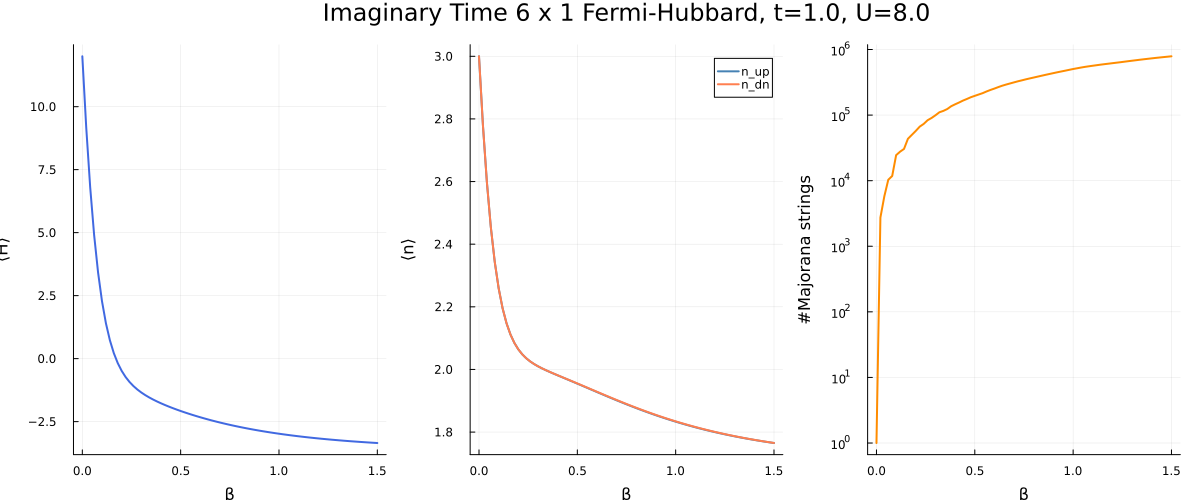

In [42]:
p_res = plot(dt*(0:n_layers)./ t, res, label="", xlabel="β", ylabel="⟨H⟩", lw=2, color=:royalblue)
p_densities = plot(dt*(0:n_layers)./ t, [n_up_res n_dn_res], label=["n_up" "n_dn"], xlabel="β", ylabel="⟨n⟩", lw=2, color=[:steelblue :coral])
p_length = plot(dt*(0:n_layers)./ t, length_res, label="", xlabel="β", ylabel="#Majorana strings", yscale=:log10, lw=2, color=:darkorange)    

plot(p_res, p_densities, p_length, layout=(1,3), size=(1200,500), margin=3mm, suptitle="Imaginary Time $N_x x $N_y Fermi-Hubbard, t=$t, U=$U")